# Proyecto de regresión logística

En este notebook voy a hacer el proyecto de regresión logística paso a paso.  
La idea es entender mejor los datos, hacer un pequeño EDA, preparar el dataset correctamente y luego entrenar un modelo sencillo para predecir la variable objetivo.


## 1. Importar librerías

Primero importo todas las librerías que voy a usar en el proyecto.  
Las dejo juntas desde el principio para tener el notebook más ordenado.


In [3]:
import sys
!{sys.executable} -m pip install seaborn -q


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
from pickle import dump

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 2. Cargar los datos

Aquí cargo el dataset desde la URL del ejercicio.  
Así trabajo directamente con los datos sin necesidad de descargarlos manualmente.


In [5]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv"
total_data = pd.read_csv(url, sep=";")
total_data.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Revisión rápida

Antes de empezar con el modelo, reviso el tamaño del dataset, los duplicados, los nulos y los tipos de datos para entender un poco mejor qué tengo delante.


In [6]:
total_data.shape


(41188, 21)

In [7]:
total_data.duplicated().sum()


np.int64(12)

In [8]:
total_data.isnull().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [9]:
total_data.dtypes


age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

## 4. Limpieza inicial

En este caso no hay nulos, pero sí hay algunos registros duplicados, así que los elimino antes de seguir.


In [10]:
total_data = total_data.drop_duplicates().reset_index(drop=True)
total_data.shape


(41176, 21)

## 5. EDA de la variable objetivo

Primero miro cómo está repartida la variable objetivo.  
Esto es importante porque si las clases están desbalanceadas luego conviene tenerlo en cuenta en el split y en el modelo.


In [11]:
total_data["y"].value_counts()


y
no     36537
yes     4639
Name: count, dtype: int64

In [12]:
(total_data["y"].value_counts(normalize=True) * 100).round(2)


y
no     88.73
yes    11.27
Name: proportion, dtype: float64

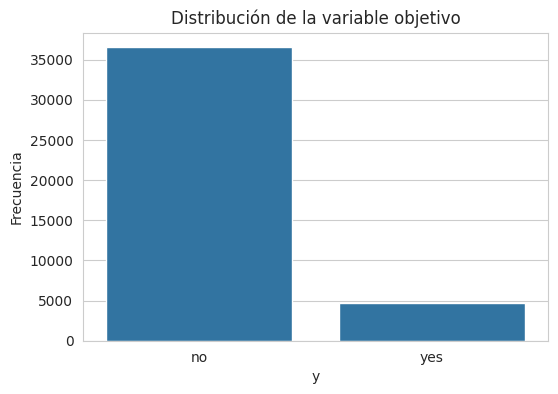

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=total_data, x="y")
plt.title("Distribución de la variable objetivo")
plt.xlabel("y")
plt.ylabel("Frecuencia")
plt.show()


## 6. EDA de variables numéricas

Aquí reviso las variables numéricas con histogramas para ver su distribución y también hago boxplots para detectar posibles valores extremos.


In [14]:
numeric_cols = total_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols


['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

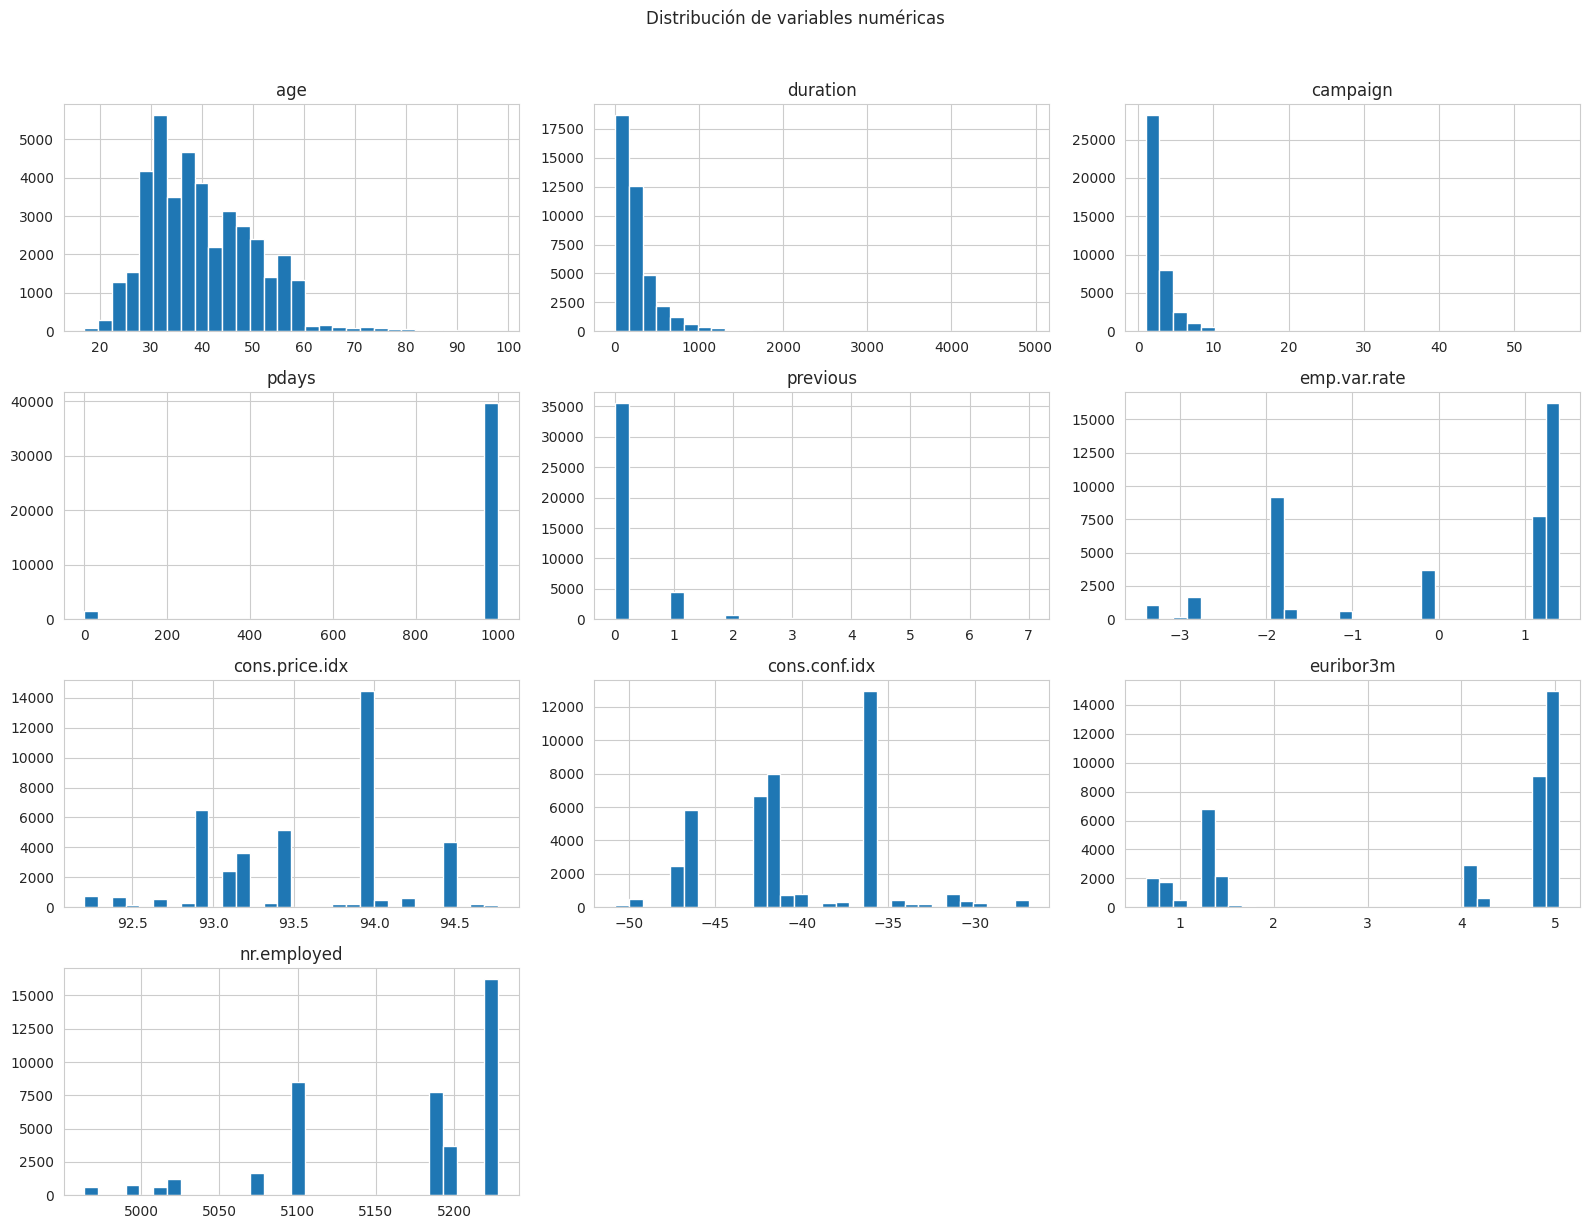

In [15]:
total_data[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribución de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()


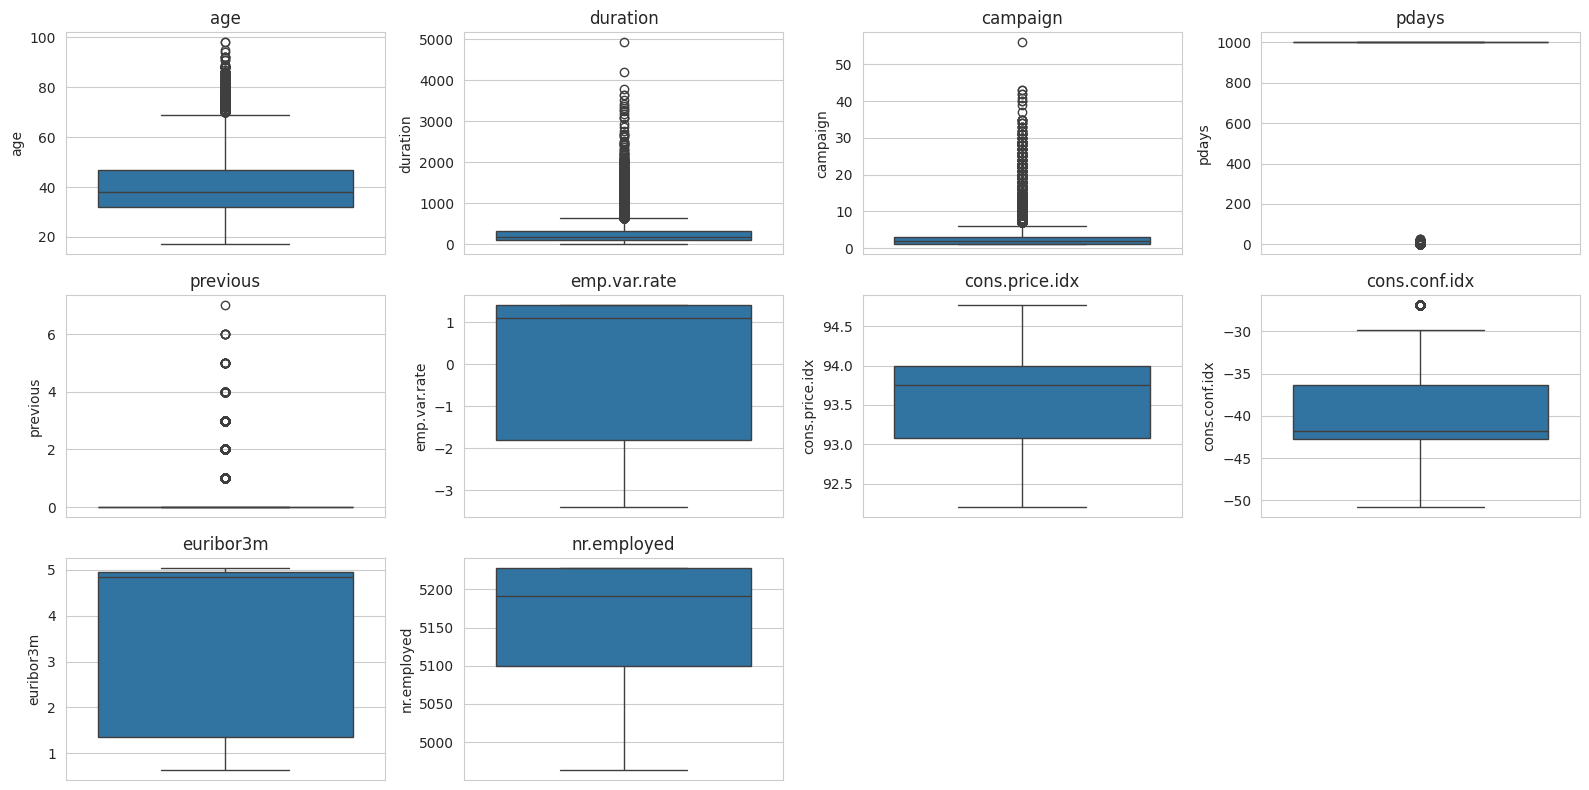

In [16]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=total_data[col])
    plt.title(col)
plt.tight_layout()
plt.show()


## 7. EDA de variables categóricas

También reviso algunas de las variables categóricas más importantes para ver cómo están distribuidas.


In [17]:
categorical_cols = total_data.select_dtypes(include=["object"]).columns.tolist()
categorical_cols


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

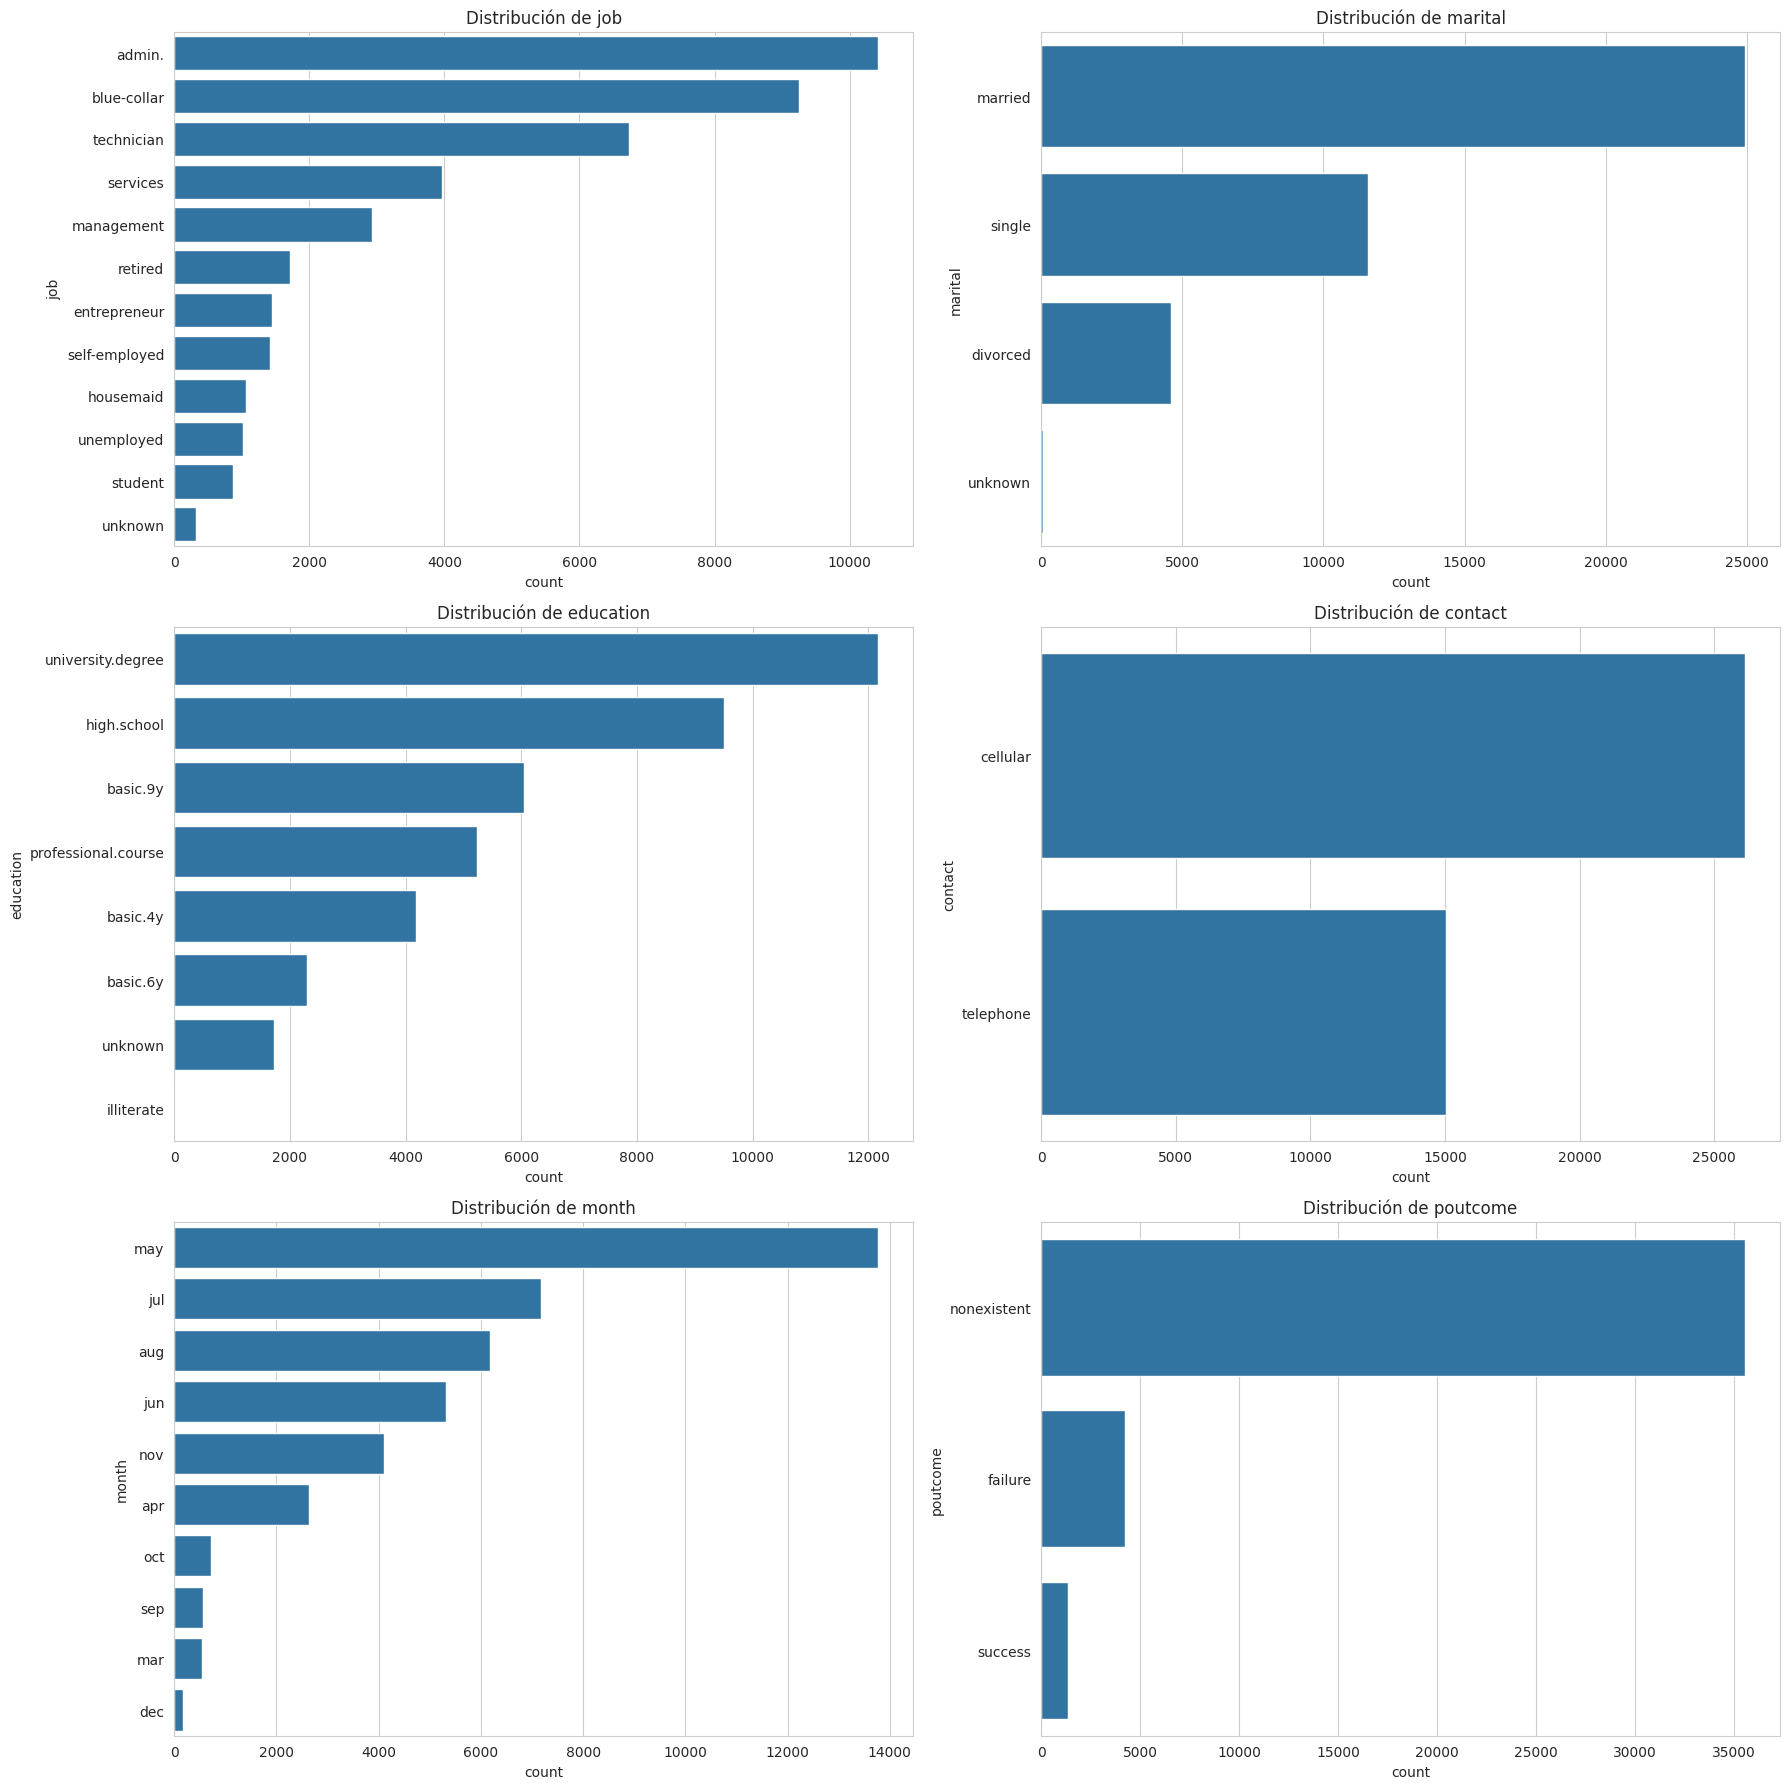

In [18]:
eda_cats = ["job", "marital", "education", "contact", "month", "poutcome"]

plt.figure(figsize=(18, 18))
for i, col in enumerate(eda_cats, 1):
    plt.subplot(3, 2, i)
    order = total_data[col].value_counts().index
    sns.countplot(data=total_data, y=col, order=order)
    plt.title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


## 8. Heatmap de relaciones

Para ver relaciones entre variables numéricas, hago un heatmap de correlación.  
Aquí convierto la variable objetivo a 0 y 1 solo para poder incluirla en esta visualización.


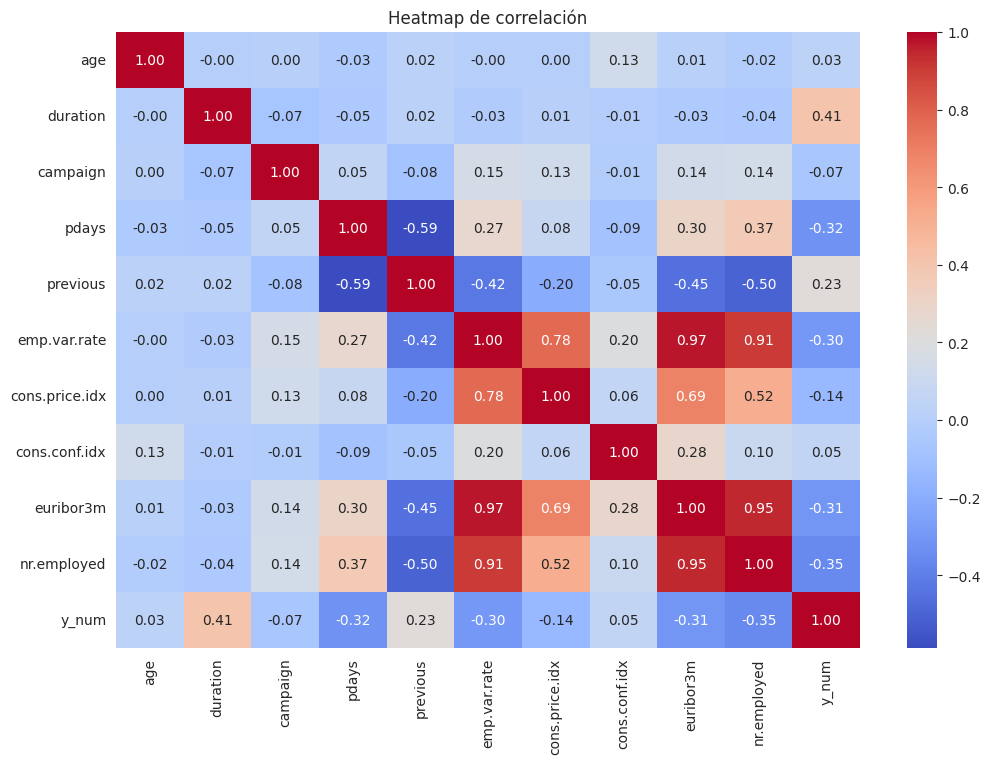

In [19]:
eda_data = total_data.copy()
eda_data["y_num"] = eda_data["y"].map({"no": 0, "yes": 1})

corr_cols = numeric_cols + ["y_num"]
corr_matrix = eda_data[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap de correlación")
plt.show()


## 9. Decisiones antes del modelado

Después de revisar los datos, tomo algunas decisiones:

- Elimino duplicados.
- La variable objetivo está desbalanceada, así que usaré `stratify` en el split.
- También probaré `class_weight='balanced'` en la regresión logística.
- No voy a usar `factorize` para las variables categóricas, porque no es la mejor opción para este modelo.
- En su lugar usaré `OneHotEncoder` dentro de un pipeline.
- Además elimino la variable `duration`, porque puede producir data leakage: esa información solo se conoce al final de la llamada y no sería válida en un escenario real de predicción.


## 10. Preparar X e y

Aquí separo las variables predictoras y la variable objetivo.  
También elimino `duration` por el problema de leakage comentado antes.


In [20]:
model_data = total_data.copy()
model_data = model_data.drop(columns=["duration"])

X = model_data.drop(columns=["y"])
y = model_data["y"].map({"no": 0, "yes": 1})

X.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


## 11. Train y test

Ahora hago la separación entre train y test.  
En este caso uso `stratify` para mantener la proporción de clases, y dejo un 20% para test.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape


((32940, 19), (8236, 19))

In [22]:
y_train.value_counts(normalize=True).round(4), y_test.value_counts(normalize=True).round(4)


(y
 0    0.8873
 1    0.1127
 Name: proportion, dtype: float64,
 y
 0    0.8873
 1    0.1127
 Name: proportion, dtype: float64)

## 12. Preprocesado

Como tengo variables numéricas y categóricas, preparo un pipeline para tratarlas de forma correcta.  
Las numéricas las imputo y escalo, y las categóricas las imputo y las transformo con One Hot Encoding.


In [23]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## 13. Selección de variables y modelo base del pipeline

Aquí monto ya el pipeline completo con el preprocesado, la selección de variables y la regresión logística.  
La selección la hago con `SelectKBest` y después probaré varios valores de `k`.


In [24]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selectk", SelectKBest(score_func=chi2)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])


## 14. Pequeña optimización

Pruebo varios valores de `k`, distintos valores de `C` y dos solvers diferentes para ver qué combinación funciona mejor.


In [25]:
grid = GridSearchCV(
    pipeline,
    {
        "selectk__k": [3, 5, 7, 10],
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"]
    },
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)
grid.best_params_


{'model__C': 10, 'model__solver': 'lbfgs', 'selectk__k': 10}

In [26]:
grid.best_score_


np.float64(0.3912777713843626)

## 15. Evaluación del mejor modelo

Una vez encontrada la mejor combinación, evalúo el modelo en el conjunto de test.


In [27]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_pred[:10]


array([0, 1, 0, 1, 0, 0, 1, 0, 1, 0])

In [28]:
accuracy_score(y_test, y_pred)


0.7703982515784361

In [29]:
y_proba = best_model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_proba)


0.7913741200007549

In [30]:
confusion_matrix(y_test, y_pred)


array([[5695, 1613],
       [ 278,  650]])

In [31]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.78      0.86      7308
           1       0.29      0.70      0.41       928

    accuracy                           0.77      8236
   macro avg       0.62      0.74      0.63      8236
weighted avg       0.88      0.77      0.81      8236



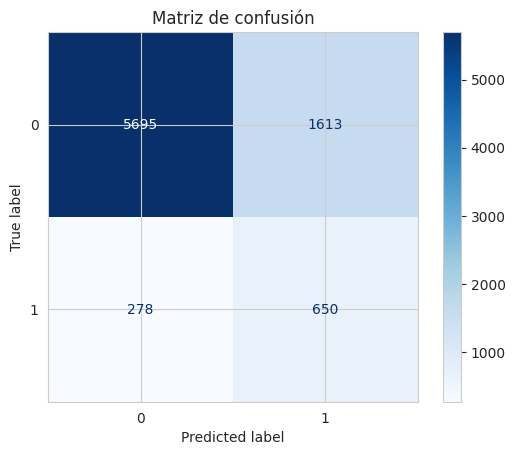

In [32]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()


## 16. Variables seleccionadas

Como estoy usando un pipeline con codificación y selección de variables, aquí saco los nombres de las columnas que finalmente se han quedado en el modelo.


In [33]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
selected_mask = best_model.named_steps["selectk"].get_support()
selected_features = feature_names[selected_mask]

selected_features


array(['num__previous', 'num__emp.var.rate', 'num__euribor3m',
       'num__nr.employed', 'cat__job_student', 'cat__contact_telephone',
       'cat__month_mar', 'cat__month_oct', 'cat__month_sep',
       'cat__poutcome_success'], dtype=object)

## 17. Guardar datos limpios

Guardo una copia del train y del test por si luego quiero reutilizarlos por separado.


In [34]:
os.makedirs("data/processed", exist_ok=True)

train_data = X_train.copy()
train_data["y"] = y_train.values

test_data = X_test.copy()
test_data["y"] = y_test.values

train_data.to_csv("data/processed/clean_train.csv", index=False)
test_data.to_csv("data/processed/clean_test.csv", index=False)


In [35]:
pd.read_csv("data/processed/clean_train.csv").head()


ParserError: Error tokenizing data. C error: Expected 5 fields in line 1071, saw 20


## 18. Guardar el modelo

Por último guardo el pipeline completo con el mejor modelo encontrado.


In [ ]:
os.makedirs("models", exist_ok=True)
dump(best_model, open("models/logistic_regression_pipeline.sav", "wb"))


## Conclusión

En este proyecto he cargado el dataset, he hecho una revisión inicial, un pequeño EDA con visualizaciones, he limpiado los datos y he preparado correctamente las variables para entrenar una regresión logística.

También he tenido en cuenta el desbalanceo de la variable objetivo usando `stratify` en la separación de train y test y `class_weight='balanced'` en el modelo.  
Además, para evitar problemas de data leakage, he eliminado la variable `duration` y he hecho el preprocesado dentro de un pipeline.

Por último, he probado varias configuraciones con `GridSearchCV` para quedarme con la mejor combinación posible dentro de este enfoque.
